In [189]:
import tensorflow as tf
import keras 
from tensorflow.keras.layers import Input, Lambda, Dense, Flatten, Dropout
from keras.callbacks import EarlyStopping,ModelCheckpoint
from tensorflow.keras.models import Model
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
import itertools

In [190]:
IMAGE_SIZE = [224, 224]
epochs = 10
batch_size = 64

In [191]:
# Get test and train data from directory
trainingData = '/Users/daniellorenzen/Desktop/MachineLearning/Mammals/mammalsData/trainingData'
testData = '/Users/daniellorenzen/Desktop/MachineLearning/Mammals/mammalsData/testData'


In [192]:
image_files = glob(trainingData + '/*/*.jp*g')
folders = glob(trainingData + '/*')

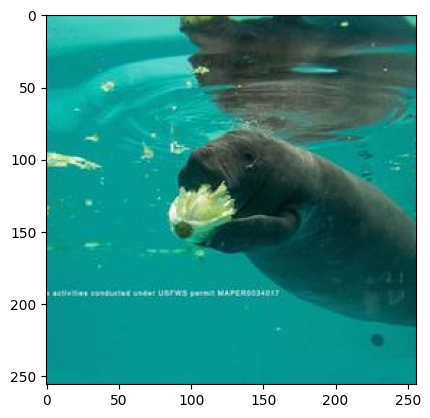

In [193]:
plt.imshow(image.load_img(np.random.choice(image_files)))

In [194]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

restNet = ResNet50(input_shape=IMAGE_SIZE + [3], weights='imagenet', include_top=False)

In [195]:
for layer in restNet.layers[: -10]:
    layer.trainable = False

In [196]:
base_model = tf.keras.applications.MobileNetV3Small(input_shape=(224,224,3),include_top=False,weights='imagenet')
base_model.trainable = False
keras_model=keras.models.Sequential()
keras_model.add(base_model)
keras_model.add(keras.layers.Flatten()) 
keras_model.add(keras.layers.Dropout(0.5))
keras_model.add(keras.layers.Dense(45,activation=tf.nn.softmax))
keras_model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 MobilenetV3small (Function  (None, 7, 7, 576)         939120    
 al)                                                             
                                                                 
 flatten_10 (Flatten)        (None, 28224)             0         
                                                                 
 dropout_10 (Dropout)        (None, 28224)             0         
                                                                 
 dense_24 (Dense)            (None, 45)                1270125   
                                                                 
Total params: 2209245 (8.43 MB)
Trainable params: 1270125 (4.85 MB)
Non-trainable params: 939120 (3.58 MB)
_________________________________________________________________


In [197]:
#model = Model(inputs=restNet.input, outputs=layers)

In [198]:
#model.summary()

In [199]:
target_size=(224,224)
validation_split=0.2

trainSet = tf.keras.preprocessing.image_dataset_from_directory(
    trainingData,
    validation_split=validation_split,
    subset="training",
    seed=100,
    image_size=target_size,
    batch_size=batch_size,
)

testSet = tf.keras.preprocessing.image_dataset_from_directory(
    trainingData,
    validation_split=validation_split,
    subset="validation",
    seed=200,
    image_size=target_size,
    batch_size=batch_size,
)

Found 13751 files belonging to 45 classes.
Using 11001 files for training.
Found 13751 files belonging to 45 classes.
Using 2750 files for validation.


In [200]:
print(len(testSet))
validation_steps = len(testSet) // batch_size
print(validation_steps)

43
0


In [201]:
keras_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = keras_model.fit(trainSet, validation_data=testSet, epochs=epochs)

Epoch 1/10


172/172 [==============================] - 22s 119ms/step - loss: 3.6239 - accuracy: 0.6146 - val_loss: 0.5843 - val_accuracy: 0.9211
Epoch 2/10
172/172 [==============================] - 20s 117ms/step - loss: 0.8274 - accuracy: 0.8986 - val_loss: 0.5553 - val_accuracy: 0.9411
Epoch 3/10
172/172 [==============================] - 20s 117ms/step - loss: 0.4363 - accuracy: 0.9410 - val_loss: 0.5502 - val_accuracy: 0.9524
Epoch 4/10
172/172 [==============================] - 20s 116ms/step - loss: 0.3948 - accuracy: 0.9515 - val_loss: 0.5529 - val_accuracy: 0.9524
Epoch 5/10
172/172 [==============================] - 20s 115ms/step - loss: 0.3974 - accuracy: 0.9540 - val_loss: 0.5663 - val_accuracy: 0.9571
Epoch 6/10
172/172 [==============================] - 20s 117ms/step - loss: 0.3924 - accuracy: 0.9596 - val_loss: 0.5769 - val_accuracy: 0.9593
Epoch 7/10
172/172 [==============================] - 20s 118ms/step - loss: 0.3606 - accuracy: 0.9623 - val_loss: 0.6702 - val_accuracy: 0.9

In [202]:
class_labels = testSet.class_names

1/1 [==============================] - 0s 29ms/step
[[0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


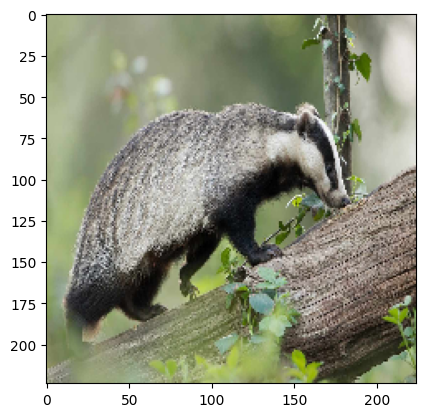

In [207]:
test_image = image.load_img('/Users/daniellorenzen/Desktop/MachineLearning/Mammals/mammalsData/funTesting/GettyImages-170437062-6f90a2438a4243e485bcbc4ce9955f90.jpg', target_size=(224, 224))
plt.imshow(test_image)
test_image = image.img_to_array(test_image)
test_image = np.expand_dims(test_image, axis=0)
result = keras_model.predict(test_image)
np.set_printoptions(suppress=True, precision=5)
print(result)

In [208]:
max_index = np.argmax(result)

# Get the corresponding class label
predicted_class = class_labels[max_index]

# Print the predicted class
print("Predicted mammal:", predicted_class)

Predicted mammal: badger
